In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial

PDK.activate()

## MMI 2X2 (VÉRTICES)

2026-06-04 11:13:46.416 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/2308182294.oas'


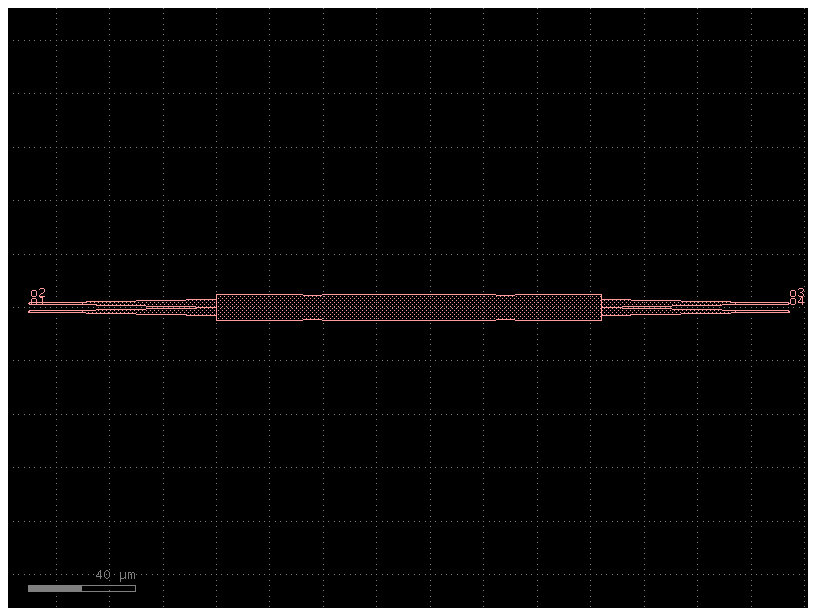

In [15]:
def b_symmetric_body_vertices(L_mmi, W_mmi, W_narrow):
    return np.array(
        [
            #body mmi
            # parte abajo: mirar dibujo libreta
            (0.0,          -W_mmi / 2), #p1
            (L_mmi / 4,    -W_narrow / 2), #p2
            (L_mmi / 2,    -W_mmi / 2), #p3
            (3*L_mmi / 4,  -W_narrow / 2),
            (L_mmi,        -W_mmi / 2),

            # parte arriba: mirar dibujo libreta
            (L_mmi,         W_mmi / 2), #p6
            (3*L_mmi / 4,   W_narrow / 2),
            (L_mmi / 2,     W_mmi / 2),
            (L_mmi / 4,     W_narrow / 2),
            (0.0,           W_mmi / 2),
        ]
    )

import numpy as np


# -------------------------
# TAPERS IZQUIERDA
# -------------------------

def taper_bottom_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, -W_mmi / 2 + d_io),
            (0.0, -W_mmi / 2 + d_io + Wt),

            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def taper_top_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, W_mmi / 2 - d_io - Wt),
            (0.0, W_mmi / 2 - d_io),

            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# TAPERS DERECHA
# -------------------------

def taper_bottom_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, -W_mmi / 2 + d_io),
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi, -W_mmi / 2 + d_io + Wt),
        ]
    )


def taper_top_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, W_mmi / 2 - d_io - Wt),
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi, W_mmi / 2 - d_io),
        ]
    )


# -------------------------
# GUÍAS IZQUIERDA
# -------------------------

def wg_bottom_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (-lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (-lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (-lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (-lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# GUÍAS DERECHA
# -------------------------

def wg_bottom_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )

def b_symmetric_mmi_vertices(
    L_mmi,
    W_mmi,
    W_narrow,
    L_wg,
    lt,
    wt,
    Wt,
    d_io,
):
    return {
        "mmi": b_symmetric_body_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            W_narrow=W_narrow,
        ),

        "in_bot_taper": taper_bottom_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_taper": taper_top_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_taper": taper_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_taper": taper_top_right_vertices(

            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_bot_wg": wg_bottom_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_wg": wg_top_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_wg": wg_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_wg": wg_top_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),
    }

L_mmi = 144
W_mmi = 10
W_narrow = 10-0.72
L_wg = 20
lt = 50
wt = 1.0
Wt = 3
d_io = 1.97

polys = b_symmetric_mmi_vertices(
    L_mmi=L_mmi,
    W_mmi=W_mmi,
    W_narrow=W_narrow,
    L_wg=L_wg,
    lt=lt,
    wt=wt,
    Wt=Wt,
    d_io=d_io,
)

mmi95 = gf.Component()
for poly in polys.values():
    mmi95.add_polygon(poly, layer="WG")

y_bot = -W_mmi / 2 + d_io + Wt / 2
y_top = W_mmi / 2 - d_io - Wt / 2

x_left = -lt - L_wg
x_right = L_mmi + lt + L_wg

mmi95.add_port(
    name="o1",
    center=(x_left, y_bot),
    width=wt,
    orientation=180,
    layer="WG",
)

mmi95.add_port(
    name="o2",
    center=(x_left, y_top),
    width=wt,
    orientation=180,
    layer="WG",
)

mmi95.add_port(
    name="o3",
    center=(x_right, y_top),
    width=wt,
    orientation=0,
    layer="WG",
)

mmi95.add_port(
    name="o4",
    center=(x_right, y_bot),
    width=wt,
    orientation=0,
    layer="WG",
)

mmi95.draw_ports()
mmi95.plot()
mmi95.show()

2026-06-04 11:15:45.011 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/813029881.oas'


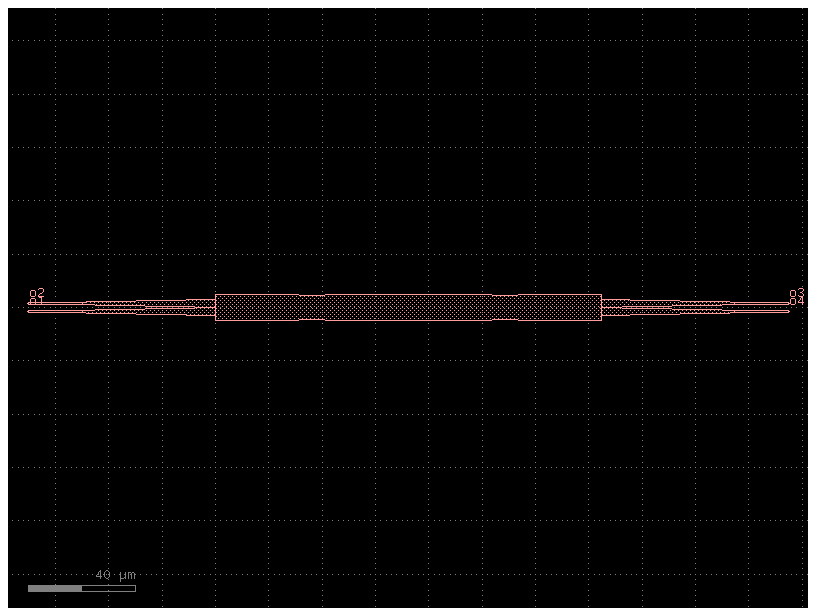

In [17]:
def b_symmetric_mmi(L_mmi=144.7, W_mmi=10, Aw = 0.72, L_wg=20, lt=50, wt=1.0, Wt=3, d_io=1.97, layer="WG"):

    c = gf.Component()
    W_narrow= W_mmi - Aw

    #vértices ( mismos que uso en la simulación de tidy)

    polys = {
        "mmi": [
            (0.0,         -W_mmi / 2),
            (L_mmi / 4,   -W_narrow / 2),
            (L_mmi / 2,   -W_mmi / 2),
            (3*L_mmi / 4, -W_narrow / 2),
            (L_mmi,       -W_mmi / 2),
            (L_mmi,        W_mmi / 2),
            (3*L_mmi / 4,  W_narrow / 2),
            (L_mmi / 2,    W_mmi / 2),
            (L_mmi / 4,    W_narrow / 2),
            (0.0,          W_mmi / 2),
        ],

        "in_bot_taper": [
            (-lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (0.0, -W_mmi / 2 + d_io),
            (0.0, -W_mmi / 2 + d_io + Wt),
            (-lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ],

        "in_top_taper": [
            (-lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (0.0, W_mmi / 2 - d_io - Wt),
            (0.0, W_mmi / 2 - d_io),
            (-lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ],

        "out_bot_taper": [
            (L_mmi, -W_mmi / 2 + d_io),
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi, -W_mmi / 2 + d_io + Wt),
        ],

        "out_top_taper": [
            (L_mmi, W_mmi / 2 - d_io - Wt),
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi, W_mmi / 2 - d_io),
        ],

        "in_bot_wg": [
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (-lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (-lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ],

        "in_top_wg": [
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (-lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (-lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ],

        "out_bot_wg": [
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ],

        "out_top_wg": [
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ],
    }

    for poly in polys.values():
        c.add_polygon(np.array(poly), layer=layer)

    y_bot = -W_mmi / 2 + d_io + Wt / 2
    y_top = W_mmi / 2 - d_io - Wt / 2
    x_left = -lt - L_wg
    x_right = L_mmi + lt + L_wg

    for name, center, orientation in [
        ("o1", (x_left, y_bot), 180),
        ("o2", (x_left, y_top), 180),
        ("o3", (x_right, y_top), 0),
        ("o4", (x_right, y_bot), 0),
    ]:
        c.add_port(
            name=name,
            center=center,
            width=wt,
            orientation=orientation,
            layer=layer,
        )

    return c

mmi95 = b_symmetric_mmi()

mmi95.draw_ports()
mmi95.plot()
mmi95.show()
    


## MMI TEST STRUCTURES 2X2

2026-06-04 09:20:53.260 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/1007440263.oas'


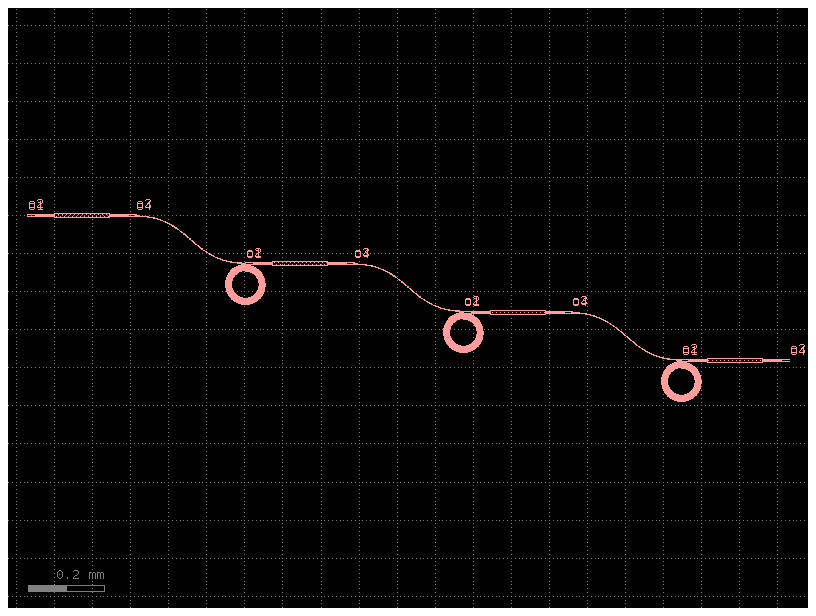

In [12]:
casc_A  = cells.mmi_ts(mmi95, 3000, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

2026-06-04 09:19:13.550 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/863658286.oas'


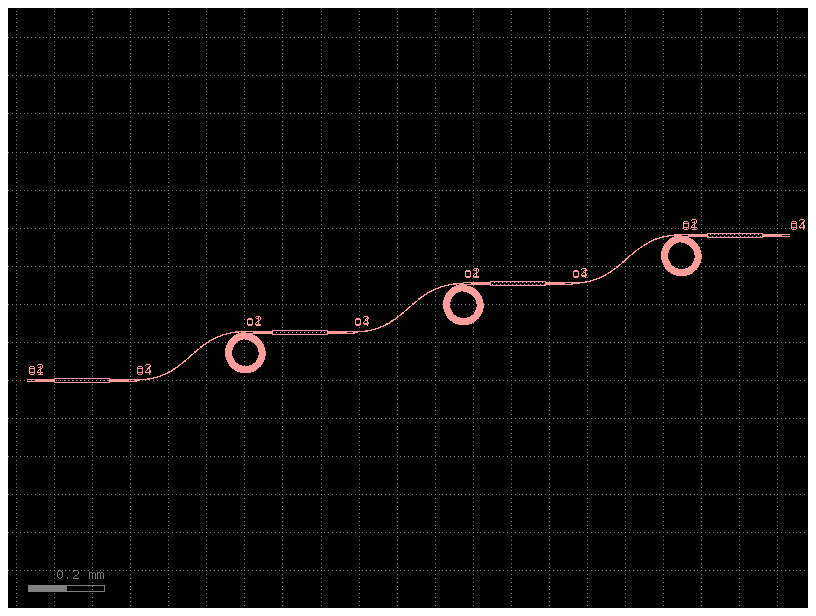

In [ ]:
casc_B  = cells.mmi_ts(mmi95, 3000, 500,  add_terminators=True)
casc_B.plot()
casc_B.show()

## WAVLENGTH TRACKER NUEVO

2026-06-04 13:52:21.001 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2898516966.oas'


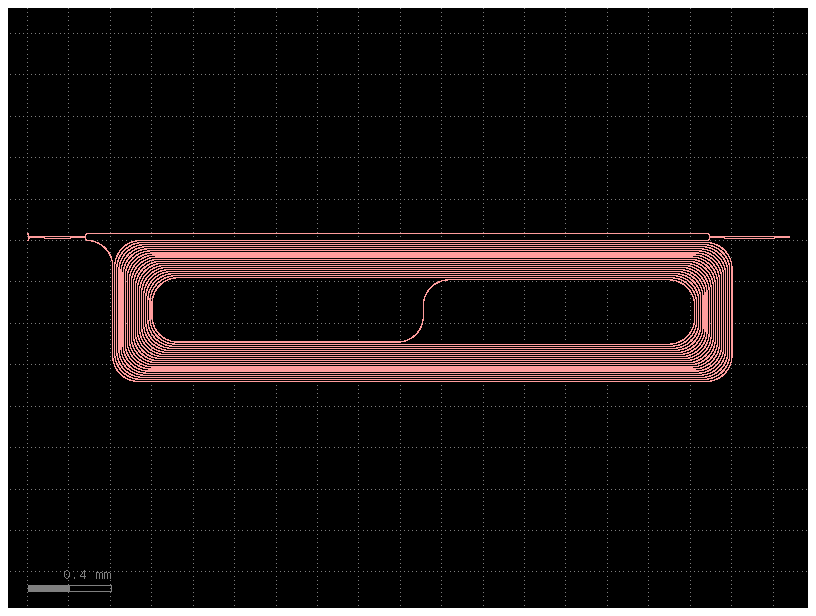

In [5]:
# N espiral TIENE QUE SER PAR
from upvfab.sin300.cband.tech import LAYER, TECH
import numpy as np


def wvl_tracker(length_spiral: float = 2120.00732421875, L = 3000,  length_mmi_2x2: float =126.3,  taper_length = 50 + 20,   length_mmi_3x3: float =  242.4723, taper_width_mmi_3x3: float = 2.8, gap_mmi_3x3: float = 0.2,  width: float = TECH.width, radius: float =  TECH.radius): #mejorarlo poniendo las funciones de espiral dentro
    c = gf.Component()
   
    mmi_95 = c << cells.mmi_2x2_bends(length_mmi_2x2)
    mmi_33 = c << cells.mmi3x3(width, width_taper=taper_width_mmi_3x3, length_taper= taper_length, length_mmi = length_mmi_3x3, width_mmi= 10, gap_mmi = gap_mmi_3x3)
    spiral = c << cells.spiral_upv(radius = radius, N_spr = 18 , d_SPR =10 , dx_SPR= length_spiral, dy_SPR = 50.46, layer = "strip") # N must BE EVEN 

    
    
    # h = spiral.ports["o2"].dx - spiral.ports["o1"].dx
    wvg_up = c << gf.components.straight(length = L, cross_section= "strip", width = width)

    dy_mmi95 = mmi_95.ports["o3"].dy - mmi_95.ports["o4"].dy #para conectar los s_bend de forma que las entradas a los mmi queden a la misma altura
    dy_mmi33 = mmi_33.ports["o3"].dy - mmi_33.ports["o1"].dy
    h_bends_33 = ( dy_mmi95 - dy_mmi33)/2
    b3 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = width, allow_min_radius_violation = True)
    b4 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = width, allow_min_radius_violation = True)

    wvg_up.dmove((mmi_95.ports['o3'].dx, mmi_95.ports['o3'].dy))
    b3.dmirror_y()
    b3.dmove((wvg_up.ports['o2'].dx, wvg_up.ports['o2'].dy))
    mmi_33.dmove((b3.ports['o2'].dx + taper_length, b3.ports['o2'].dy - 3)) # 3 = Wt
    b4.dmirror_x()
    b4.dmirror_y()
    b4.dmove((mmi_33.ports['o2'].dx, mmi_33.ports['o1'].dy))
    
    dx_spiral = np.abs(mmi_95.ports['o4'].dx - spiral.ports['o1'].dx)
    dy_spiral = np.abs(mmi_95.ports['o4'].dy - spiral.ports['o1'].dy)

    spiral.dmove((dx_spiral, -dy_spiral))

    

    #  #bends entrada y salida cto
    # b5 = c <<cells.bend_s(size = [10, 15], cross_section = "strip", width = width, allow_min_radius_violation = True)
    # b6 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = width, allow_min_radius_violation = True)
    # b5.mirror_x()
    # b5.mirror_y()
    # b5.dmovex(mmi_95.ports["o2"].dx).dmovey(mmi_95.ports["o2"].dy)
    # b6.mirror_x()
    # b6.dmovex(mmi_95.ports["o1"].dx).dmovey(mmi_95.ports["o1"].dy)
    # b7 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = width, allow_min_radius_violation = True)
    # b8 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = width, allow_min_radius_violation = True)
    # wvg = c << gf.components.straight(10, cross_section = "strip")
    # b7.mirror_y()
    # b8.dmovex(mmi_33.ports["o4"].dx).dmovey(mmi_33.ports["o4"].dy)
    # b7.dmovex(mmi_33.ports["o6"].dx).dmovey(mmi_33.ports["o6"].dy)
    # wvg.dmovex(mmi_33.ports["o5"].dx).dmovey(mmi_33.ports["o5"].dy)



    # c.add_port(name = "o1", port = b6.ports["o2"], port_type= "optical")
    # c.add_port(name = "o2", port = b5.ports["o2"], port_type= "optical")
    # c.add_port(name = "o3", port = b8.ports["o2"], port_type= "optical")
    # c.add_port(name = "o4", port = wvg.ports["o2"], port_type= "optical")
    # c.add_port(name = "o5", port = b7.ports["o2"], port_type= "optical")


    # c.info["total_length_device"] = 2*taper_length + length_mmi_2x2 + 2*10 + h  + 2*taper_length + length_mmi_3x3 #2*10 es de los sbends
    # c.info["length_short_arm"] = h + 2*10
    # c.info["h_bends_33"] = h_bends_33

    # #normalizar posición para que quede en (0,0)
    
    # x0, y0 = c.ports["o1"].dcenter
    # c.dmove((-x0, -y0))

    return c 
test = wvl_tracker()
test.plot()
test.show()